In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
%matplotlib inline
df = pd.read_csv(r"E:\computer science (Mostafa)\IEEE AI Task\IEEE-AI-Ambassadors-2026\Task_09\CC GENERAL.csv")
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


## Data Exploration 

In [2]:
df.shape

(8950, 18)

In [3]:
df.ndim

2

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [5]:
miss = df.isnull().sum().sort_values(ascending=False)
miss_per = ((df.isnull().sum() / len(df)) * 100).round(2).sort_values(ascending=False)
pd.DataFrame({"Missing Values": miss, "Missing Percentage": miss_per})[miss > 0]

,Missing Values,Missing Percentage
MINIMUM_PAYMENTS,313,3.50
CREDIT_LIMIT,1,0.01


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
skewness = df.skew(numeric_only=True).sort_values(ascending=False)
print(skewness)

MINIMUM_PAYMENTS                    13.622797
ONEOFF_PURCHASES                    10.045083
PURCHASES                            8.144269
INSTALLMENTS_PURCHASES               7.299120
PAYMENTS                             5.907620
CASH_ADVANCE_TRX                     5.721298
CASH_ADVANCE                         5.166609
PURCHASES_TRX                        4.630655
BALANCE                              2.393386
PRC_FULL_PAYMENT                     1.942820
CASH_ADVANCE_FREQUENCY               1.828686
ONEOFF_PURCHASES_FREQUENCY           1.535613
CREDIT_LIMIT                         1.522464
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
PURCHASES_FREQUENCY                  0.060164
BALANCE_FREQUENCY                   -2.023266
TENURE                              -2.943017
dtype: float64


In [8]:
df.drop("CUST_ID", axis=1, inplace=True)


In [9]:
for i in df.columns :
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    Lower_ = Q1 - 1.5 * IQR
    Upper_ = Q3 + 1.5 * IQR
    Outlier = df[(df[i] < Lower_) | (df[i] > Upper_)]
    print("_____________________________________")
    print(f"Name of Column: {i}")
    print("Number Of Outlier : ",len(Outlier))
    print(f"Lower : {Lower_}")
    print(f"Upper : {Upper_}")
  

_____________________________________
Name of Column: BALANCE
Number Of Outlier :  695
Lower : -2760.5052645
Upper : 4942.9272155
_____________________________________
Name of Column: BALANCE_FREQUENCY
Number Of Outlier :  1493
Lower : 0.7222225000000001
Upper : 1.1666664999999998
_____________________________________
Name of Column: PURCHASES
Number Of Outlier :  808
Lower : -1566.1075000000003
Upper : 2715.8725000000004
_____________________________________
Name of Column: ONEOFF_PURCHASES
Number Of Outlier :  1013
Lower : -866.1075
Upper : 1443.5124999999998
_____________________________________
Name of Column: INSTALLMENTS_PURCHASES
Number Of Outlier :  867
Lower : -702.95625
Upper : 1171.59375
_____________________________________
Name of Column: CASH_ADVANCE
Number Of Outlier :  1030
Lower : -1670.7317088750003
Upper : 2784.5528481250003
_____________________________________
Name of Column: PURCHASES_FREQUENCY
Number Of Outlier :  0
Lower : -1.166668
Upper : 2.166668
____________

## Fill NAN Values

In [10]:
from sklearn.impute import SimpleImputer
import pandas as pd

imputer = SimpleImputer(strategy="median")

df = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns,
    index=df.index
)

## Outlier Remove

In [11]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (df < lower_bound) |
    (df > upper_bound)
).any(axis=1)

df_clean = df.loc[~outlier_mask].copy()

print("Original:", df.shape)
print("Cleaned:", df_clean.shape)
print("Removed:", outlier_mask.sum())

Original: (8950, 17)
Cleaned: (2986, 17)
Removed: 5964


## Log Transformation and  Feature Scaling  

In [12]:
X_train , X_test = train_test_split(df_clean ,random_state=42 ,train_size = 0.8)

In [13]:
X_train_log = np.log1p(X_train)
X_test_log = np.log1p(X_test)

In [14]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

In [15]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)

In [16]:
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)

In [17]:
skewnesss = X_train_log.skew()
print(skewnesss)

BALANCE                            -1.270751
BALANCE_FREQUENCY                  -3.171567
PURCHASES                          -0.682554
ONEOFF_PURCHASES                    0.311453
INSTALLMENTS_PURCHASES              0.103184
CASH_ADVANCE                        0.117435
PURCHASES_FREQUENCY                 0.242212
ONEOFF_PURCHASES_FREQUENCY          1.486096
PURCHASES_INSTALLMENTS_FREQUENCY    0.640185
CASH_ADVANCE_FREQUENCY              0.995285
CASH_ADVANCE_TRX                    0.569907
PURCHASES_TRX                      -0.071056
CREDIT_LIMIT                        0.130578
PAYMENTS                           -2.695866
MINIMUM_PAYMENTS                   -0.392864
PRC_FULL_PAYMENT                    2.652895
TENURE                              0.000000
dtype: float64


In [18]:
skewnessss = X_test_log.skew()
print(skewnessss)

BALANCE                            -1.114845
BALANCE_FREQUENCY                  -2.808366
PURCHASES                          -0.601937
ONEOFF_PURCHASES                    0.283912
INSTALLMENTS_PURCHASES              0.233745
CASH_ADVANCE                        0.127292
PURCHASES_FREQUENCY                 0.327086
ONEOFF_PURCHASES_FREQUENCY          1.399439
PURCHASES_INSTALLMENTS_FREQUENCY    0.764895
CASH_ADVANCE_FREQUENCY              1.101484
CASH_ADVANCE_TRX                    0.623130
PURCHASES_TRX                      -0.001310
CREDIT_LIMIT                       -0.053280
PAYMENTS                           -2.707536
MINIMUM_PAYMENTS                   -0.258595
PRC_FULL_PAYMENT                    2.305483
TENURE                              0.000000
dtype: float64


## Kmeans

In [19]:
kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

train_clusters = kmeans_final.fit_predict(X_train_scaled)
test_clusters = kmeans_final.predict(X_test_scaled)

In [20]:
X_train_clustered = X_train_scaled.copy()

X_train_clustered['Cluster'] = train_clusters

In [21]:
inertias = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)

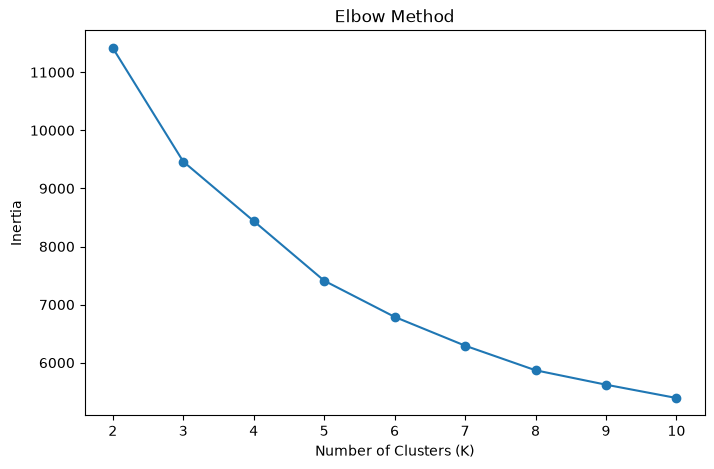

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertias, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

In [23]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_train_scaled)
    
    score = silhouette_score(X_train_scaled, labels)
    silhouette_scores.append(score)

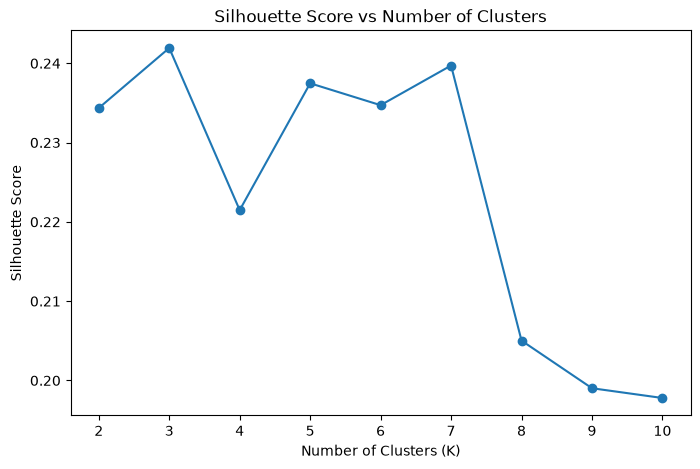

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')

plt.show()

In [25]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

train_clusters = kmeans.fit_predict(X_train_scaled)

X_train_clustered = X_train_scaled.copy()
X_train_clustered["Cluster"] = train_clusters

In [26]:
X_train_clustered["Cluster"].value_counts().sort_index()

Cluster
0    845
1    504
2    421
3    618
Name: count, dtype: int64

In [27]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(
    X_train_pca,
    columns=["PC1", "PC2"],
    index=X_train_scaled.index
)

pca_df["Cluster"] = train_clusters

pca_df.head()

,PC1,PC2,Cluster
7640,-1.395676,0.071213,1
2254,0.492368,0.654931,1
3418,-0.390508,-0.198259,3
5893,1.586844,1.302354,1
4783,-1.606806,0.924657,1


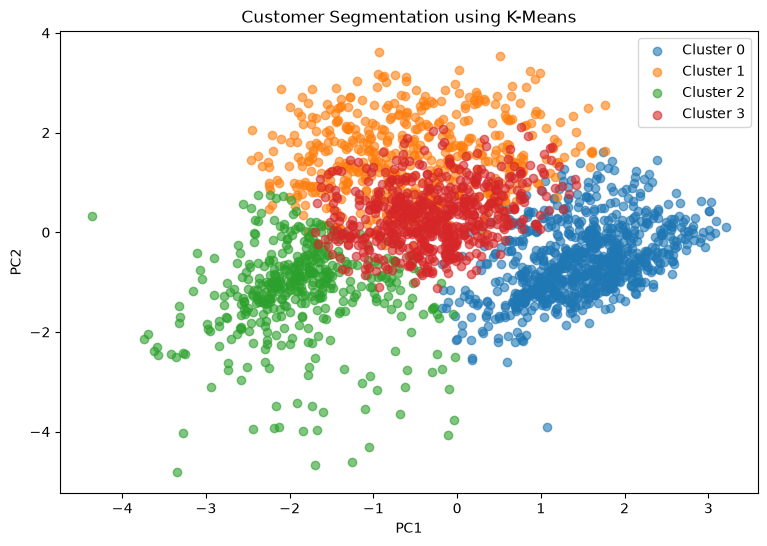

In [28]:
plt.figure(figsize=(9, 6))

for cluster in sorted(pca_df["Cluster"].unique()):
    cluster_data = pca_df[pca_df["Cluster"] == cluster]
    
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segmentation using K-Means")
plt.legend()

plt.show()

In [29]:
cluster_profile = X_train.copy()

cluster_profile["Cluster"] = train_clusters

cluster_profile.groupby("Cluster").mean()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1641.933860,0.986444,50.508450,36.834746,13.697373,866.447233,0.042801,0.020710,0.019527,0.209961,3.653254,0.697041,2914.497041,883.840896,533.062141,0.015380,12.0
1,1304.197897,0.979077,864.425099,637.732837,227.444008,268.213663,0.602348,0.388393,0.333829,0.072421,1.337302,14.938492,4087.959957,1068.619530,485.490383,0.027191,12.0
2,203.860924,0.954006,327.968314,93.708599,234.259715,61.109621,0.603919,0.060570,0.542359,0.017221,0.266033,9.783848,3032.422803,291.950146,177.310728,0.070418,12.0
3,1262.535030,0.987938,446.524434,127.754159,319.343641,188.336923,0.569579,0.052050,0.516586,0.038430,0.692557,9.988673,2984.466019,869.500621,567.611792,0.012398,12.0


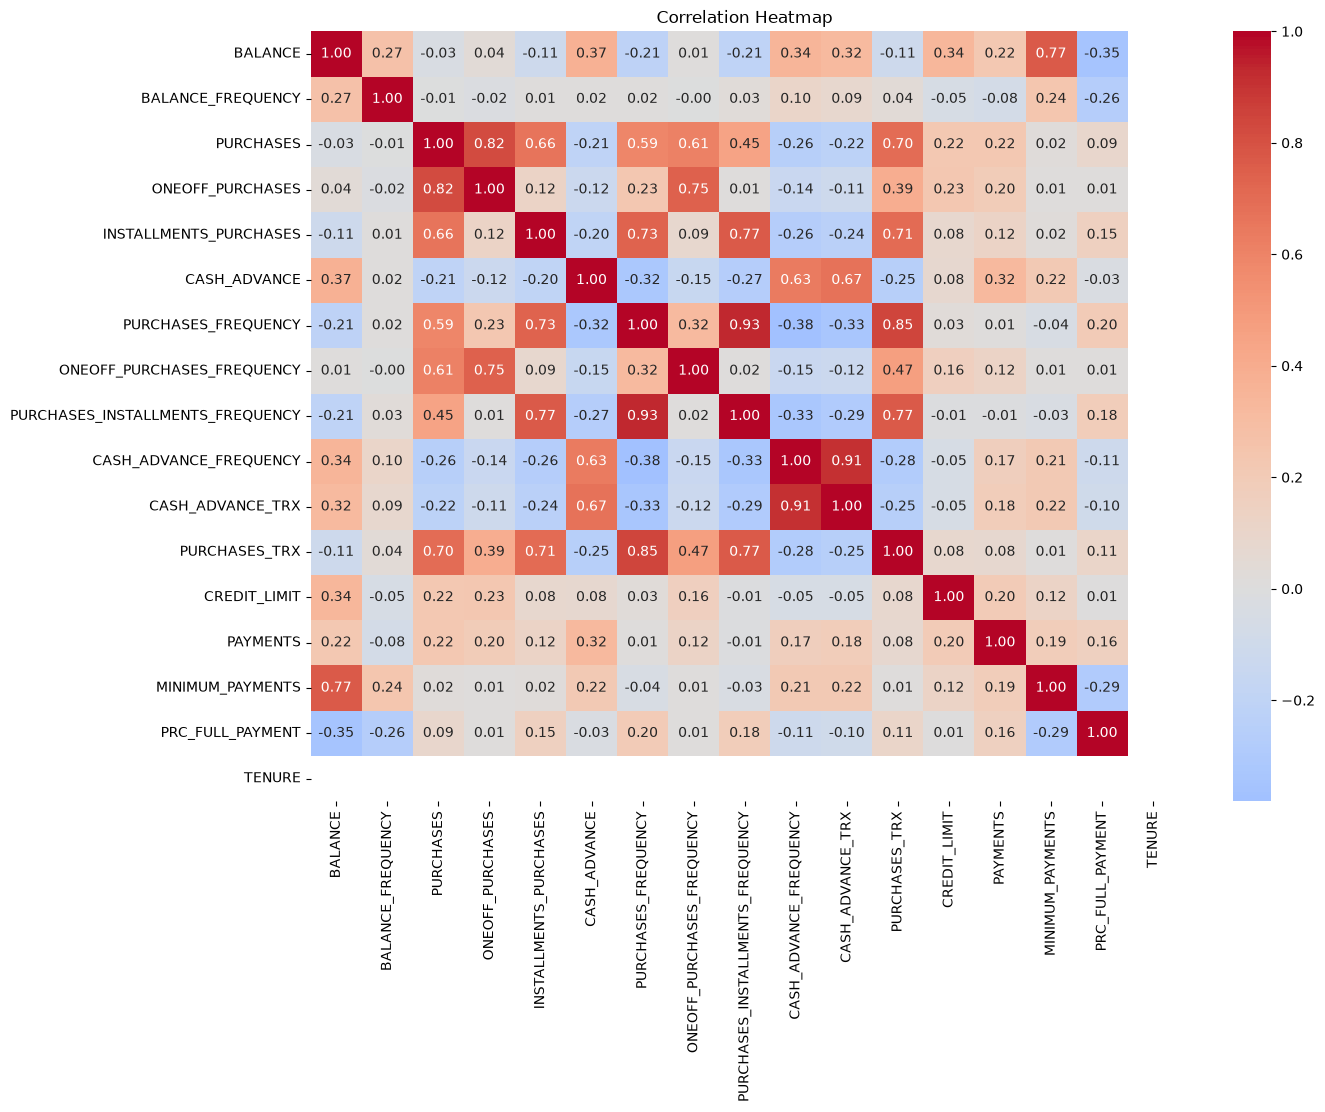

In [30]:


corr = X_train.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

In [31]:

kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

y_train = kmeans_final.fit_predict(X_train_scaled)
y_test = kmeans_final.predict(X_test_scaled)

In [32]:
print(y_train.shape)
print(y_test.shape)

(2388,)
(598,)


In [33]:
print("Train distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("Test distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Train distribution:
0    845
1    504
2    421
3    618
Name: count, dtype: int64
Test distribution:
0    221
1    135
2    117
3    125
Name: count, dtype: int64


In [34]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train_scaled, y_train)

rf_train_pred = rf.predict(X_train_scaled)
rf_test_pred = rf.predict(X_test_scaled)

In [35]:


print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_test_pred))

Random Forest Accuracy: 0.9414715719063546

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       221
           1       0.95      0.93      0.94       135
           2       0.95      0.91      0.93       117
           3       0.88      0.94      0.91       125

    accuracy                           0.94       598
   macro avg       0.94      0.94      0.94       598
weighted avg       0.94      0.94      0.94       598



In [36]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

lr_test_pred = lr.predict(X_test_scaled)

In [37]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_test_pred))

Logistic Regression Accuracy: 0.9832775919732442

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       221
           1       0.99      0.99      0.99       135
           2       0.98      0.97      0.98       117
           3       0.97      0.97      0.97       125

    accuracy                           0.98       598
   macro avg       0.98      0.98      0.98       598
weighted avg       0.98      0.98      0.98       598



In [38]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [39]:
rf = RandomForestClassifier()

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [40]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train_scaled, y_train)

train_pred = rf.predict(X_train_scaled)
test_pred = rf.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Random Forest")
print("Train Accuracy:", train_accuracy)
print("Test Accuracy :", test_accuracy)
print("Gap           :", train_accuracy - test_accuracy)

Random Forest
Train Accuracy: 1.0
Test Accuracy : 0.9414715719063546
Gap           : 0.058528428093645446


In [41]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

train_pred_log = log_reg.predict(X_train_scaled)
test_pred_log = log_reg.predict(X_test_scaled)

train_accuracy_log = accuracy_score(y_train, train_pred_log)
test_accuracy_log = accuracy_score(y_test, test_pred_log)

print("Logistic Regression")
print("Train Accuracy:", train_accuracy_log)
print("Test Accuracy :", test_accuracy_log)
print("Gap           :", train_accuracy_log - test_accuracy_log)

Logistic Regression
Train Accuracy: 0.990787269681742
Test Accuracy : 0.9832775919732442
Gap           : 0.007509677708497864


In [42]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std CV Accuracy:", cv_scores.std())

CV Scores: [0.95606695 0.958159   0.94979079 0.95597484 0.96855346]
Mean CV Accuracy: 0.9577090076576933
Std CV Accuracy: 0.006102563469888997


In [43]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Train Accuracy": [
        train_accuracy,
        train_accuracy_log
    ],
    "Test Accuracy": [
        test_accuracy,
        test_accuracy_log
    ]
})

results["Train-Test Gap"] = (
    results["Train Accuracy"] -
    results["Test Accuracy"]
)

results

,Model,Train Accuracy,Test Accuracy,Train-Test Gap
0,Random Forest,1.000000,0.941472,0.058528
1,Logistic Regression,0.990787,0.983278,0.007510


In [44]:
grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose v

In [45]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score:
0.9598019350367973


In [46]:
best_rf = grid_search.best_estimator_

best_pred = best_rf.predict(X_test_scaled)

best_test_accuracy = accuracy_score(
    y_test,
    best_pred
)

print("Tuned RF Test Accuracy:",
      best_test_accuracy)

Tuned RF Test Accuracy: 0.9431438127090301
